<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan%2013_%20Sakti%20Cristopel%20Lingga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 13 — Deep Learning & NLP Dasar

Nama Lengkap: Sakti Cristopel Lingga

NIM: 240401010125

Kelas:  IF403

Topik:
1. Neural Network untuk Klasifikasi Non-Linear
2. TF-IDF untuk Analisis Sentimen

## Deskripsi Praktikum

Praktikum ini terdiri dari dua bagian utama. Bagian pertama menggunakan Neural Network sederhana untuk melakukan klasifikasi pada dataset non-linear menggunakan dataset make_moons. Bagian kedua menggunakan TF-IDF untuk mengubah teks menjadi representasi numerik dan Logistic Regression untuk melakukan klasifikasi sentimen pada ulasan produk berbahasa Indonesia.

Melalui praktikum ini, dapat dipahami bagaimana Neural Network mampu mempelajari pola non-linear serta bagaimana teknik TF-IDF dapat digunakan sebagai dasar pemrosesan teks dalam Natural Language Processing (NLP).

## Tujuan Praktikum

Praktikum ini bertujuan untuk:

1. Memahami karakteristik data non-linear.
2. Membangun Neural Network sederhana menggunakan Keras.
3. Memahami penggunaan fungsi aktivasi ReLU dan Sigmoid.
4. Mengevaluasi performa Neural Network menggunakan data pengujian.
5. Menganalisis kurva pembelajaran untuk melihat kemungkinan overfitting.
6. Memahami konsep TF-IDF dalam pengolahan teks.
7. Mengubah ulasan produk menjadi representasi numerik.
8. Membangun model Logistic Regression untuk klasifikasi sentimen.
9. Melakukan prediksi sentimen terhadap kalimat baru.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("Library berhasil diimpor.")

Library berhasil diimpor.


## Langkah 1 — Generate dan Eksplorasi Dataset Non-Linear

Dataset make_moons terdiri dari dua kelas berbentuk bulan sabit. Bentuk data yang melengkung menyebabkan kedua kelas tidak dapat dipisahkan secara optimal hanya menggunakan satu garis lurus.

Dataset terdiri dari 300 titik data dengan dua fitur dan dua kelas. Noise sebesar 0.2 ditambahkan untuk membuat data lebih realistis.

Shape X: (300, 2)
Shape y: (300,)

Jumlah masing-masing kelas:
1    150
0    150
Name: count, dtype: int64


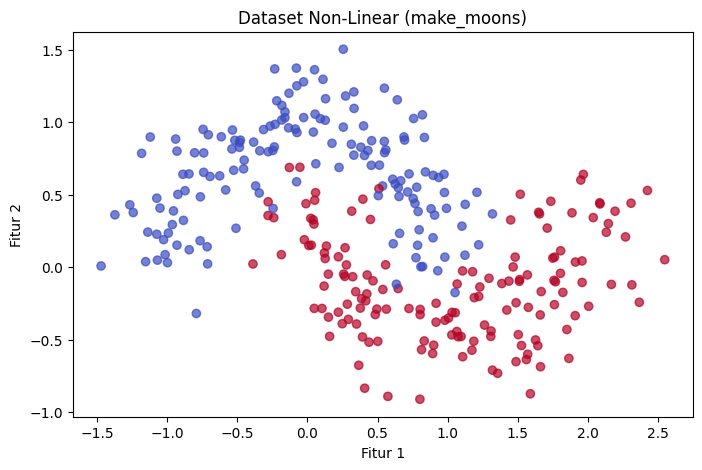

In [5]:
# Membuat dataset make_moons

X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nJumlah masing-masing kelas:")
print(pd.Series(y).value_counts())

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.title("Dataset Non-Linear (make_moons)")

plt.show()

## Interpretasi Dataset

Berdasarkan visualisasi, kedua kelas membentuk pola bulan sabit yang saling melengkung dan bertautan. Pola tersebut menunjukkan bahwa data tidak dapat dipisahkan secara optimal menggunakan satu garis lurus.

Oleh karena itu, diperlukan model yang mampu mempelajari hubungan non-linear. Neural Network dapat digunakan karena fungsi aktivasi pada hidden layer memungkinkan model mempelajari pola yang lebih kompleks.

## Langkah 2 — Pembagian Data

Dataset dibagi menjadi data training dan data testing dengan perbandingan 80:20. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi kemampuan model terhadap data yang belum pernah digunakan selama proses pelatihan.

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data training :", X_tr.shape)
print("Data testing  :", X_te.shape)

Data training : (240, 2)
Data testing  : (60, 2)


## Langkah 3 — Membangun dan Melatih Neural Network

Model Neural Network terdiri dari dua hidden layer dan satu output layer. Hidden layer pertama memiliki 16 neuron dengan fungsi aktivasi ReLU, sedangkan hidden layer kedua memiliki 8 neuron dengan fungsi aktivasi ReLU.

Output layer memiliki satu neuron dengan fungsi aktivasi Sigmoid karena masalah yang digunakan merupakan klasifikasi biner, yaitu dua kelas.

In [8]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print("Training selesai.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Training selesai.


## Langkah 4 — Evaluasi Model

Model dievaluasi menggunakan data testing yang tidak digunakan selama proses training. Metrik yang digunakan adalah loss dan accuracy.

Accuracy menunjukkan persentase prediksi yang berhasil diklasifikasikan dengan benar oleh model.

In [9]:
loss, acc = model.evaluate(
    X_te,
    y_te,
    verbose=0
)

print(f"Loss pada data uji    : {loss:.3f}")
print(f"Akurasi pada data uji : {acc:.3f}")

Loss pada data uji    : 0.417
Akurasi pada data uji : 0.900


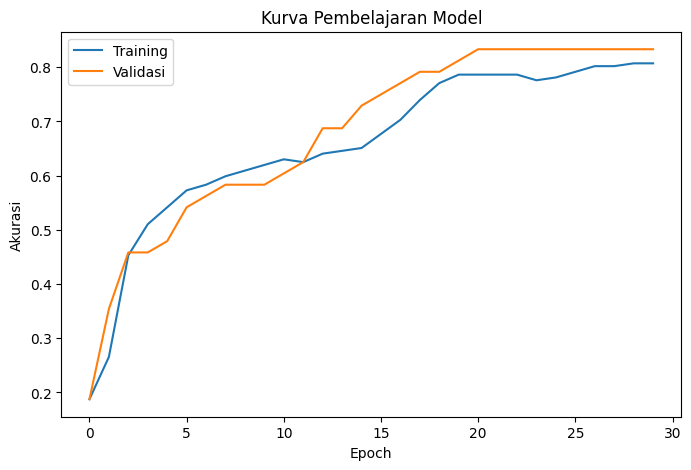

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validasi'
)

plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Pembelajaran Model")
plt.legend()

plt.show()

## Interpretasi Kurva Pembelajaran

Kurva training dan validasi digunakan untuk melihat perkembangan performa model selama proses pembelajaran.

Jika akurasi training dan validasi cenderung meningkat dan berada pada nilai yang berdekatan, maka model memiliki kemampuan generalisasi yang cukup baik. Sebaliknya, jika akurasi training meningkat jauh lebih tinggi dibandingkan validasi, kondisi tersebut dapat menjadi indikasi overfitting.

Interpretasi akhir harus disesuaikan dengan grafik yang dihasilkan oleh Google Colab.

# Bagian B — NLP dan Analisis Sentimen

## Langkah 5 — Dataset Ulasan Produk

Bagian kedua menggunakan 40 ulasan produk sintetis berbahasa Indonesia. Setiap ulasan memiliki label sentimen, yaitu 1 untuk sentimen positif dan 0 untuk sentimen negatif.

In [11]:
ulasan = [
    "Barangnya bagus banget dan kualitasnya sangat baik",
    "Pengiriman cepat dan barang sesuai deskripsi",
    "Sangat puas dengan produk ini",
    "Kualitas produk sangat bagus",
    "Barang datang tepat waktu dan aman",
    "Produknya bagus dan saya sangat puas",
    "Harga sesuai dengan kualitas barang",
    "Pelayanan sangat cepat dan memuaskan",
    "Produk berkualitas dan layak dibeli",
    "Saya suka sekali dengan produk ini",
    "Barang sesuai pesanan dan tidak mengecewakan",
    "Pengiriman cepat dan kemasan sangat rapi",
    "Produknya sangat bagus dan nyaman digunakan",
    "Sangat recommended untuk dibeli",
    "Kualitas bagus dengan harga terjangkau",
    "Saya puas dengan pelayanan toko",
    "Barangnya bekerja dengan baik",
    "Produk sesuai ekspektasi dan berkualitas",
    "Pengalaman belanja sangat menyenangkan",
    "Saya akan membeli produk ini lagi",

    "Kualitas barang jelek dan mengecewakan",
    "Pengiriman sangat lambat",
    "Barang rusak ketika sampai",
    "Produk tidak sesuai deskripsi",
    "Saya sangat kecewa dengan barang ini",
    "Pelayanan buruk dan tidak memuaskan",
    "Harga terlalu mahal untuk kualitas seperti ini",
    "Barang yang diterima sangat buruk",
    "Produk tidak bisa digunakan dengan baik",
    "Pengiriman terlambat dan mengecewakan",
    "Kualitas produk sangat rendah",
    "Barang tidak sesuai dengan pesanan",
    "Saya menyesal membeli produk ini",
    "Pelayanannya buruk sekali",
    "Produk rusak dan tidak dapat digunakan",
    "Tidak puas dengan kualitas barang",
    "Barang datang terlambat",
    "Produk sangat mengecewakan",
    "Kualitas tidak sesuai harapan",
    "Saya tidak akan membeli produk ini lagi"
]

label = [
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0
]

print("Jumlah ulasan:", len(ulasan))
print("Jumlah label :", len(label))

Jumlah ulasan: 40
Jumlah label : 40


In [12]:
df_sentimen = pd.DataFrame({
    'ulasan': ulasan,
    'label': label
})

display(df_sentimen.head(10))

print("Distribusi sentimen:")
print(
    df_sentimen['label']
    .value_counts()
    .sort_index()
)

,ulasan,label
0,Barangnya bagus banget dan kualitasnya sangat ...,1
1,Pengiriman cepat dan barang sesuai deskripsi,1
2,Sangat puas dengan produk ini,1
3,Kualitas produk sangat bagus,1
4,Barang datang tepat waktu dan aman,1
5,Produknya bagus dan saya sangat puas,1
6,Harga sesuai dengan kualitas barang,1
7,Pelayanan sangat cepat dan memuaskan,1
8,Produk berkualitas dan layak dibeli,1
9,Saya suka sekali dengan produk ini,1


Distribusi sentimen:
label
0    20
1    20
Name: count, dtype: int64


## Keterangan Label

Label 1 menunjukkan ulasan positif, sedangkan label 0 menunjukkan ulasan negatif. Dataset terdiri dari jumlah ulasan positif dan negatif yang seimbang sehingga kedua kelas memiliki representasi yang sama.

## Langkah 6 — Mengubah Teks Menjadi TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) digunakan untuk mengubah teks menjadi representasi numerik yang dapat diproses oleh algoritma Machine Learning.

TF-IDF memberikan bobot lebih tinggi pada kata yang penting dalam suatu dokumen tetapi relatif jarang muncul pada dokumen lainnya. Dengan demikian, teks dapat direpresentasikan sebagai kumpulan nilai numerik berdasarkan kata-kata yang terdapat di dalamnya.

In [13]:
tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(
    ulasan
)

print(
    "Jumlah kata unik:",
    len(tfidf.get_feature_names_out())
)

print("\n10 kata pertama:")

print(
    tfidf.get_feature_names_out()[:10]
)

print("\nShape TF-IDF:", X_text.shape)

Jumlah kata unik: 69

10 kata pertama:
['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'bekerja'
 'belanja' 'berkualitas']

Shape TF-IDF: (40, 69)


In [14]:
fitur_kata = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(
    X_text.toarray(),
    columns=fitur_kata
)

display(df_tfidf.head())

,akan,aman,bagus,baik,banget,barang,barangnya,bekerja,belanja,berkualitas,...,suka,tepat,terjangkau,terlalu,terlambat,tidak,toko,untuk,waktu,yang
0,0.0,0.000000,0.341861,0.389302,0.470402,0.000000,0.422961,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,0.316124,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.000000,0.606677,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.478661,0.000000,0.000000,0.000000,0.265339,0.000000,0.0,0.0,0.0,...,0.0,0.478661,0.0,0.0,0.0,0.0,0.0,0.0,0.478661,0.0


## Interpretasi TF-IDF

Hasil TF-IDF mengubah setiap ulasan menjadi sekumpulan nilai numerik. Setiap kolom mewakili sebuah kata, sedangkan nilai pada tabel menunjukkan bobot TF-IDF kata tersebut pada suatu ulasan.

Nilai yang lebih tinggi menunjukkan bahwa kata tersebut memiliki kontribusi yang lebih besar dalam membedakan suatu dokumen dibandingkan kata yang umum muncul pada banyak dokumen.

## Langkah 7 — Klasifikasi Sentimen dengan Logistic Regression

Representasi TF-IDF digunakan sebagai input untuk model Logistic Regression. Data dibagi menjadi data training dan testing dengan perbandingan 80:20.

Model kemudian dilatih untuk membedakan dua kelas sentimen, yaitu positif dan negatif.

In [15]:
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

print("Data training :", Xt_tr.shape)
print("Data testing  :", Xt_te.shape)

model_sentimen = LogisticRegression(
    max_iter=1000
)

model_sentimen.fit(
    Xt_tr,
    yt_tr
)

akurasi = model_sentimen.score(
    Xt_te,
    yt_te
)

print(
    f"Akurasi model sentimen: {akurasi:.3f}"
)

Data training : (32, 69)
Data testing  : (8, 69)
Akurasi model sentimen: 0.625


In [16]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

yt_pred = model_sentimen.predict(Xt_te)

print("Accuracy:", round(
    accuracy_score(yt_te, yt_pred), 3
))

print("\nConfusion Matrix:")
print(
    confusion_matrix(yt_te, yt_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        yt_te,
        yt_pred,
        target_names=[
            "Negatif",
            "Positif"
        ]
    )
)

Accuracy: 0.625

Confusion Matrix:
[[2 2]
 [1 3]]

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.67      0.50      0.57         4
     Positif       0.60      0.75      0.67         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



## Langkah 8 — Prediksi Sentimen Kalimat Baru

Model yang telah dilatih digunakan untuk memprediksi sentimen pada kalimat baru yang belum terdapat dalam dataset pelatihan.

In [17]:
kalimat_baru = [
    "Pelayanan sangat memuaskan dan ramah"
]

X_baru = tfidf.transform(
    kalimat_baru
)

pred = model_sentimen.predict(
    X_baru
)

print(
    "Kalimat:",
    kalimat_baru[0]
)

print(
    "Prediksi:",
    "Positif" if pred[0] == 1 else "Negatif"
)

Kalimat: Pelayanan sangat memuaskan dan ramah
Prediksi: Positif


# Kesimpulan

Pada praktikum ini telah dipelajari dua penerapan utama Machine Learning, yaitu Neural Network untuk klasifikasi data non-linear dan Natural Language Processing menggunakan TF-IDF untuk analisis sentimen. Dataset make_moons menunjukkan pola kelas yang melengkung sehingga diperlukan model yang mampu mempelajari hubungan non-linear, dan Neural Network digunakan untuk menangani pola tersebut. Pada bagian NLP, TF-IDF digunakan untuk mengubah ulasan produk menjadi representasi numerik yang kemudian digunakan oleh Logistic Regression untuk melakukan klasifikasi sentimen. Hasil akurasi dan kurva pembelajaran menunjukkan kemampuan model berdasarkan data yang digunakan. Keterbatasan praktikum ini adalah dataset ulasan masih berupa data sintetis dengan jumlah yang relatif kecil, sehingga performa model belum tentu sama ketika diterapkan pada ulasan produk nyata dengan variasi bahasa yang lebih kompleks.